# Fraud Detection - Capstone Project (IEEE-CIS Dataset)

### Implementation Pipeline

0. Importing Necessary Packages
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Time-Based Train/Validation Split
5. Modeling (Logistic Regression, Random Forest, LightGBM)
6. Model comparison, time-based validation, threshold tuning, feature importance (SHAP)

## 0. Importing Necessary Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, 
    precision_recall_curve, confusion_matrix, classification_report, f1_score
)
import lightgbm as gbm

### 1. Loading the Data

In [2]:
train = pd.read_csv("training_dataset_sampled.csv")
test_trans = pd.read_csv("test_transaction_sampled.csv")

## 2. Exploratory Data Analysis

### 2.1 Targeting Imbalance

In [3]:
fraud_rate = train['isFraud'].mean()
print(f"Fraud Rate: {fraud_rate: .3%}")

Fraud Rate:  3.586%


The Fraud Rate sits at 3.586%, while the Non-Fraud rate sits at 96.414%. A ratio of roughly 97:3

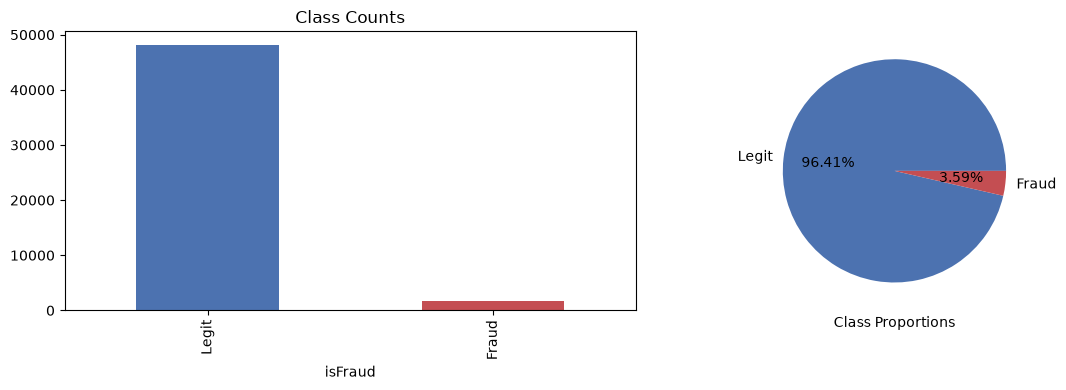

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
train['isFraud'].value_counts().plot(kind='bar', ax=ax[0], color = ['#4C72B0', '#C44E52'])
ax[0].set_title("Class Counts")
ax[0].set_xticklabels(['Legit', 'Fraud'])

train['isFraud'].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.2f%%',
                                                   labels = ['Legit', 'Fraud'], colors = ['#4C72B0', '#C44E52'])
ax[1].set_ylabel("")
ax[1].set_xlabel("Class Proportions")
plt.tight_layout()
plt.show()

### 2.2 Missingness

In [5]:
missing = train.isnull().mean().sort_values(ascending =True)
missing = missing[missing>0]
print(f"{len(missing)} columns have missing values")

382 columns have missing values


In [6]:
missing_pct = train.isna().mean() * 100

cols_to_drop = missing_pct[missing_pct > 75].index.tolist()

print(f"Dropping {len(cols_to_drop)} columns with >75% missingness:")
print(cols_to_drop)

train = train.drop(columns=cols_to_drop)

Dropping 208 columns with >75% missingness:
['dist2', 'R_emaildomain', 'D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14', 'V138', 'V139', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V160', 'V161', 'V162', 'V163', 'V164', 'V165', 'V166', 'V167', 'V168', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V177', 'V178', 'V179', 'V180', 'V181', 'V182', 'V183', 'V184', 'V185', 'V186', 'V187', 'V188', 'V189', 'V190', 'V191', 'V192', 'V193', 'V194', 'V195', 'V196', 'V197', 'V198', 'V199', 'V200', 'V201', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207', 'V208', 'V209', 'V210', 'V211', 'V212', 'V213', 'V214', 'V215', 'V216', 'V217', 'V218', 'V219', 'V220', 'V221', 'V222', 'V223', 'V224', 'V225', 'V226', 'V227', 'V228', 'V229', 'V230', 'V231', 'V232', 'V233', 'V234', 'V235', 'V236', 'V237', 'V238', 'V239', 'V240', 'V241', 'V242', 'V243', 'V244', 'V245', 'V246', 'V247', 'V24

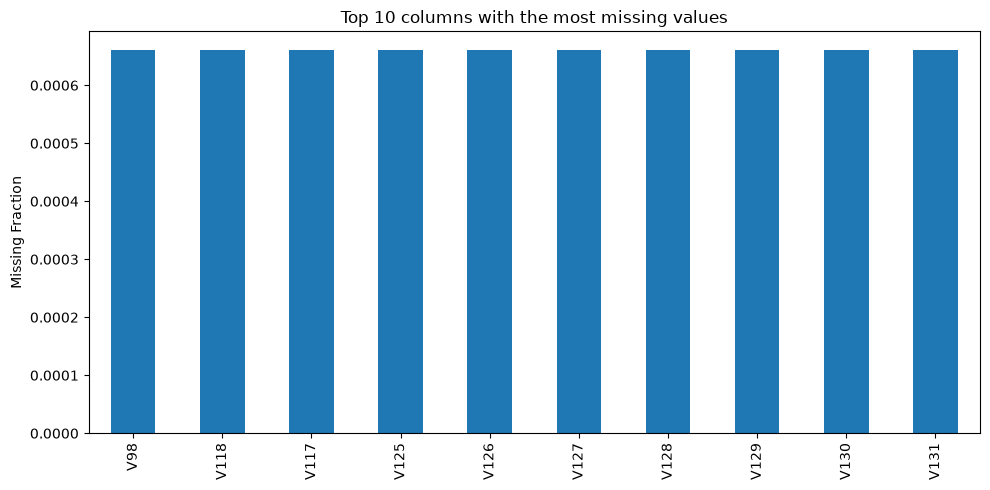

In [7]:
plt.figure(figsize=(10,5))
missing.head(10).plot(kind='bar')
plt.title("Top 10 columns with the most missing values")
plt.ylabel('Missing Fraction')
plt.tight_layout()
plt.show()

### 2.3 TransactionAmt Distribution

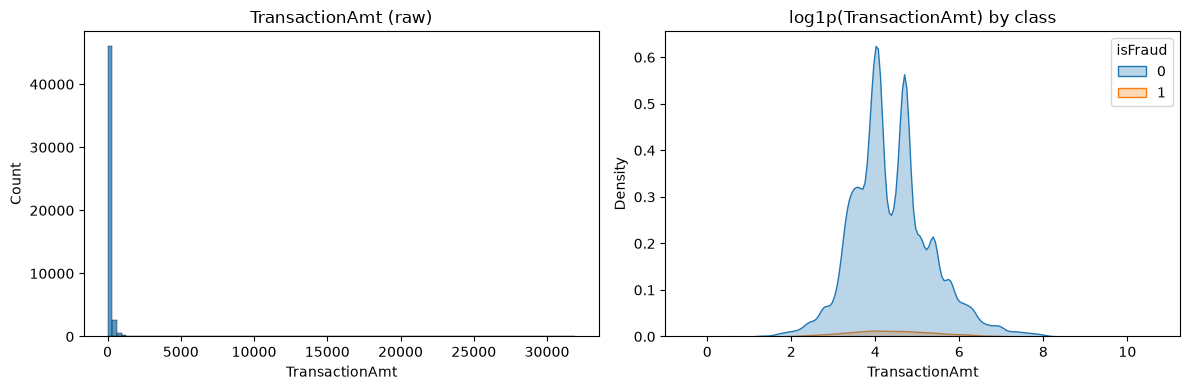

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train['TransactionAmt'], bins=100, ax=ax[0])
ax[0].set_title('TransactionAmt (raw)')

sns.kdeplot(data=train, x=np.log1p(train['TransactionAmt']), 
            hue='isFraud', ax=ax[1], fill=True, alpha=0.3)
ax[1].set_title('log1p(TransactionAmt) by class')

plt.tight_layout()
plt.show()

### 2.4 Time Structure

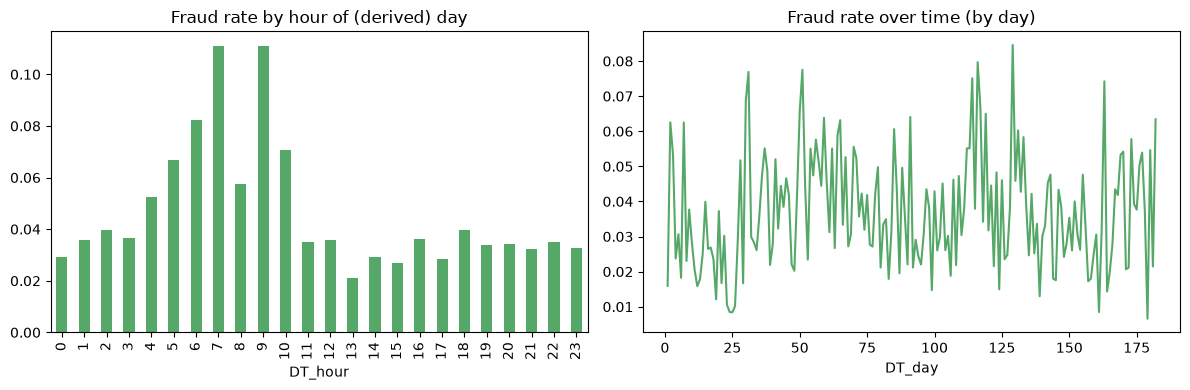

In [9]:
train['DT_day'] = train['TransactionDT'] // (24 * 60 * 60)
train['DT_hour'] = (train['TransactionDT'] // 3600) % 24

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
train.groupby('DT_hour')['isFraud'].mean().plot(kind='bar', ax=ax[0], color='#55A868')
ax[0].set_title('Fraud rate by hour of (derived) day')

train.groupby('DT_day')['isFraud'].mean().plot(ax=ax[1], color='#55A868')
ax[1].set_title('Fraud rate over time (by day)')
plt.tight_layout()
plt.show()


## 3. Feature Engineering

In [10]:
def engineer_features(df):
    df = df.copy()

   
    df['DT_day'] = df['TransactionDT'] // (24 * 60 * 60)
    df['DT_hour'] = (df['TransactionDT'] // 3600) % 24
    df['DT_dow'] = df['DT_day'] % 7

    
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
    df['TransactionAmt_decimal'] = ((df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 1000).astype(int)

    
    freq_cols = ['card1', 'card2', 'addr1', 'P_emaildomain']
    for col in freq_cols:
        if col in df.columns:
            freq = df[col].map(df[col].value_counts(dropna=False))
            df[f'{col}_freq'] = freq

    
    if 'P_emaildomain' in df.columns:
        df['P_email_suffix'] = df['P_emaildomain'].astype(str).apply(
            lambda x: x.split('.')[-1] if x != 'nan' else 'missing')

    # --- Pseudo user-ID from stable identifiers, for per-user aggregates ---
    uid_cols = [c for c in ['card1', 'card2', 'card3', 'card5', 'addr1'] if c in df.columns]
    df['uid'] = df[uid_cols].astype(str).agg('_'.join, axis=1)

    # --- Per-user aggregates ---
    user_amt_mean = df.groupby('uid')['TransactionAmt'].transform('mean')
    user_amt_std = df.groupby('uid')['TransactionAmt'].transform('std')
    user_txn_count = df.groupby('uid')['TransactionAmt'].transform('count')

    df['uid_amt_mean'] = user_amt_mean
    df['uid_amt_std'] = user_amt_std
    df['uid_txn_count'] = user_txn_count
    df['amt_to_uid_mean_ratio'] = df['TransactionAmt'] / (df['uid_amt_mean'] + 1e-3)

    # --- Missing-value indicators for a few informative V-columns ---
    for col in ['V1', 'V2', 'V3']:
        if col in df.columns:
            df[f'{col}_isna'] = df[col].isna().astype(int)

    return df

train_fe = engineer_features(train)
print(train_fe.shape)


(50000, 244)


### 3.1 Encoding Remaining Categoricals

In [11]:
cat_cols = train_fe.select_dtypes(include='object').columns.tolist()
print(f'{len(cat_cols)} categorical columns: {cat_cols[:10]}...')

from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    train_fe[col] = train_fe[col].astype(str)
    le = LabelEncoder()
    train_fe[col] = le.fit_transform(train_fe[col])


15 categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6']...


## 4. Time-Based Train/Validation Split

In [12]:
target = 'isFraud'
drop_cols = ['isFraud', 'TransactionID', 'TransactionDT']
feature_cols = [c for c in train_fe.columns if c not in drop_cols]

train_fe_sorted = train_fe.sort_values('TransactionDT')
split_idx = int(len(train_fe_sorted) * 0.8)

X_train = train_fe_sorted.iloc[:split_idx][feature_cols]
y_train = train_fe_sorted.iloc[:split_idx][target]
X_val = train_fe_sorted.iloc[split_idx:][feature_cols]
y_val = train_fe_sorted.iloc[split_idx:][target]

print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Train fraud rate: {y_train.mean():.4%}, Val fraud rate: {y_val.mean():.4%}')


Train: (40000, 241), Val: (10000, 241)
Train fraud rate: 3.6150%, Val fraud rate: 3.4700%


## 5. Modeling

### 5.1 Logistic Regression - Baseline

In [13]:
RANDOM_STATE = 42

X_train_lr = X_train.fillna(-999)
X_val_lr = X_val.fillna(-999)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lr)
X_val_scaled = scaler.transform(X_val_lr)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)

lr_probs = lr.predict_proba(X_val_scaled)[:, 1]
print(f'LR  AUC-ROC: {roc_auc_score(y_val, lr_probs):.4f}')
print(f'LR  AUC-PR : {average_precision_score(y_val, lr_probs):.4f}')


LR  AUC-ROC: 0.8186
LR  AUC-PR : 0.1366


### 5.2 Random Forest

In [14]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=20,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train.fillna(-999), y_train)

rf_probs = rf.predict_proba(X_val.fillna(-999))[:, 1]
print(f'RF  AUC-ROC: {roc_auc_score(y_val, rf_probs):.4f}')
print(f'RF  AUC-PR : {average_precision_score(y_val, rf_probs):.4f}')


RF  AUC-ROC: 0.8588
RF  AUC-PR : 0.4262


### 5.3 LightGBM (Main Model)

In [15]:
lgb_train = gbm.Dataset(X_train, label=y_train)
lgb_val = gbm.Dataset(X_val, label=y_val, reference=lgb_train)

# scale_pos_weight to address the ~3.5% positive rate
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.02,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'scale_pos_weight': scale_pos_weight,
    'verbose': -1,
    'seed': RANDOM_STATE,
}

lgb_model = gbm.train(
    params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=[gbm.early_stopping(100), gbm.log_evaluation(100)]
)

lgb_probs = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
print(f'\nLightGBM AUC-ROC: {roc_auc_score(y_val, lgb_probs):.4f}')
print(f'LightGBM AUC-PR : {average_precision_score(y_val, lgb_probs):.4f}')


Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.98725	val's auc: 0.87394
[200]	train's auc: 0.995249	val's auc: 0.881076
[300]	train's auc: 0.998013	val's auc: 0.884301
[400]	train's auc: 0.99916	val's auc: 0.885562
[500]	train's auc: 0.999605	val's auc: 0.886626
Early stopping, best iteration is:
[463]	train's auc: 0.999482	val's auc: 0.88705

LightGBM AUC-ROC: 0.8870
LightGBM AUC-PR : 0.4855


### 5.4 CatBoost (Extra)

In [16]:
from catboost import CatBoostClassifier, Pool

cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

train_pool = Pool(
    X_train_lr,
    y_train,
    cat_features=cat_features
)
val_pool = Pool(
    X_val_lr,
    y_val,
    cat_features=cat_features
)

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100  
)

catboost_model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50,
    plot=True 
)

catboost_probs = catboost_model.predict_proba(X_val_lr)[:, 1]
print(f'CatBoost AUC-ROC: {roc_auc_score(y_val, catboost_probs):.4f}')
print(f'CatBoost AUC-PR: {average_precision_score(y_val, catboost_probs):.4f}')

feature_importance = catboost_model.get_feature_importance()
important_features = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
print(important_features.head(20))

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.6823211	best: 0.6823211 (0)	total: 187ms	remaining: 1m 33s
100:	test: 0.8625923	best: 0.8625923 (100)	total: 3.61s	remaining: 14.3s
200:	test: 0.8719827	best: 0.8723508 (199)	total: 6.63s	remaining: 9.87s
300:	test: 0.8789945	best: 0.8790390 (294)	total: 10.3s	remaining: 6.79s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8790580701
bestIteration = 303

Shrink model to first 304 iterations.
CatBoost AUC-ROC: 0.8791
CatBoost AUC-PR: 0.4517
                feature  importance
12                   C1    5.365327
24                  C13    4.452927
223              DT_day    4.001473
234        uid_amt_mean    3.191738
25                  C14    3.143636
228          card1_freq    2.840535
7                 card6    2.598772
233                 uid    2.171714
13                   C2    2.012956
231  P_emaildomain_freq    1.975333
226  TransactionAmt_log    1.761947
111                 V69    1.558587
3                 card2    1.453312
72                  

## 6. Model Comparison

In [17]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM', 'CatBoost'],
    'AUC-ROC': [roc_auc_score(y_val, lr_probs), roc_auc_score(y_val, rf_probs), roc_auc_score(y_val, lgb_probs), roc_auc_score(y_val, catboost_probs)],
    'AUC-PR':  [average_precision_score(y_val, lr_probs), average_precision_score(y_val, rf_probs), average_precision_score(y_val, lgb_probs), average_precision_score(y_val, catboost_probs)],
})
results


,Model,AUC-ROC,AUC-PR
0,Logistic Regression,0.818628,0.136646
1,Random Forest,0.858791,0.426208
2,LightGBM,0.887050,0.485470
3,CatBoost,0.879058,0.451749


### 6.1 ROC and Precision-Recall Curves

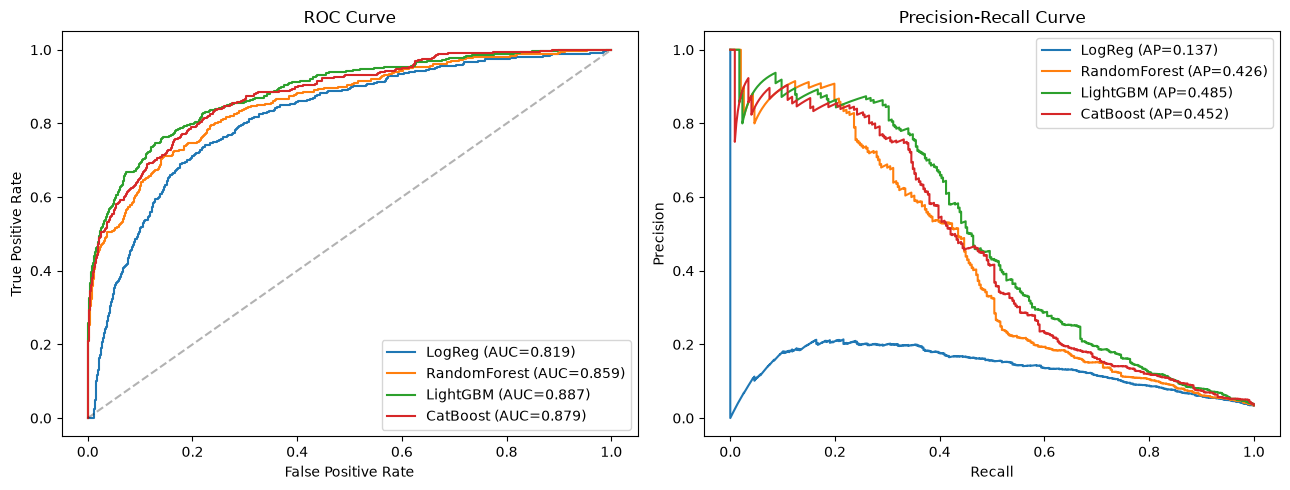

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for probs, name in [(lr_probs, 'LogReg'), (rf_probs, 'RandomForest'), (lgb_probs, 'LightGBM'), (catboost_probs, 'CatBoost')]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    ax[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val, probs):.3f})')

    prec, rec, _ = precision_recall_curve(y_val, probs)
    ax[1].plot(rec, prec, label=f'{name} (AP={average_precision_score(y_val, probs):.3f})')

ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax[0].set_xlabel('False Positive Rate'); ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve'); ax[0].legend()

ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve'); ax[1].legend()
plt.tight_layout()
plt.show()


### 6.2 Threshold Tuning

Best threshold: 0.6237, F1: 0.5026
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      9653
           1       0.64      0.41      0.50       347

    accuracy                           0.97     10000
   macro avg       0.81      0.70      0.74     10000
weighted avg       0.97      0.97      0.97     10000



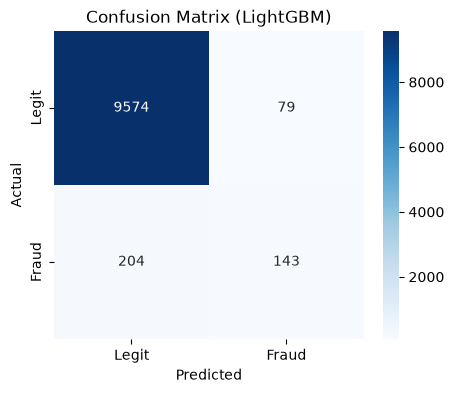

In [ ]:
prec, rec, thresholds = precision_recall_curve(y_val, lgb_probs)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f'Best threshold: {best_threshold:.4f}, F1: {f1_scores[best_idx]:.4f}')

y_pred = (lgb_probs >= best_threshold).astype(int)
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (LightGBM)')
plt.show()


### 6.3 Feature Importance

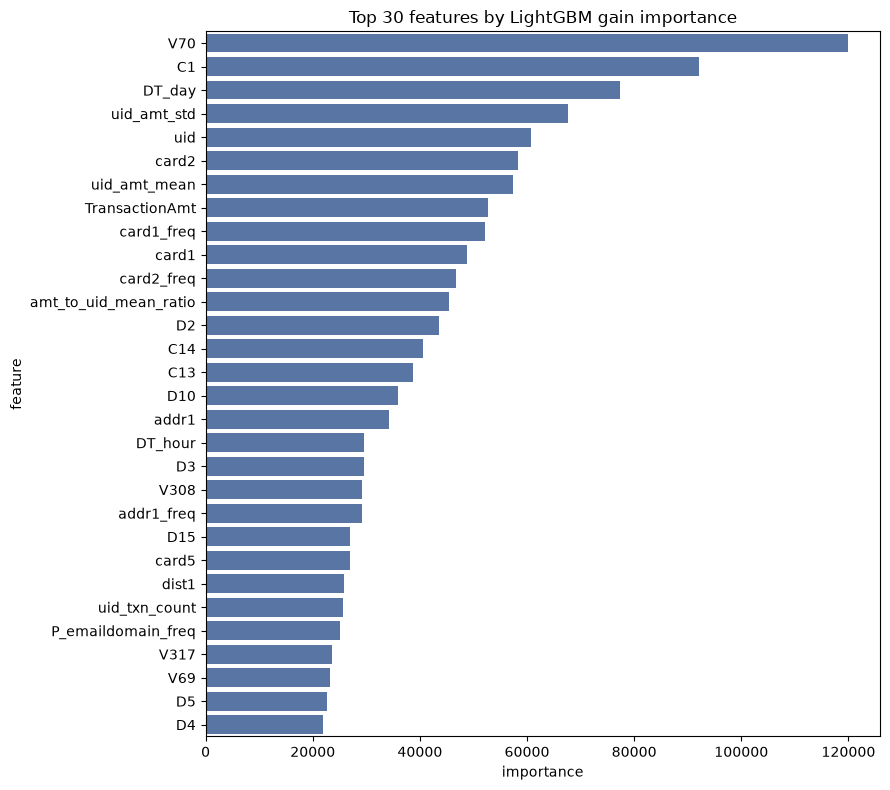

In [ ]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).head(30)

plt.figure(figsize=(9, 8))
sns.barplot(data=importance, x='importance', y='feature', color='#4C72B0')
plt.title('Top 30 features by LightGBM gain importance')
plt.tight_layout()
plt.show()


### 6.4 SHAP Explainability

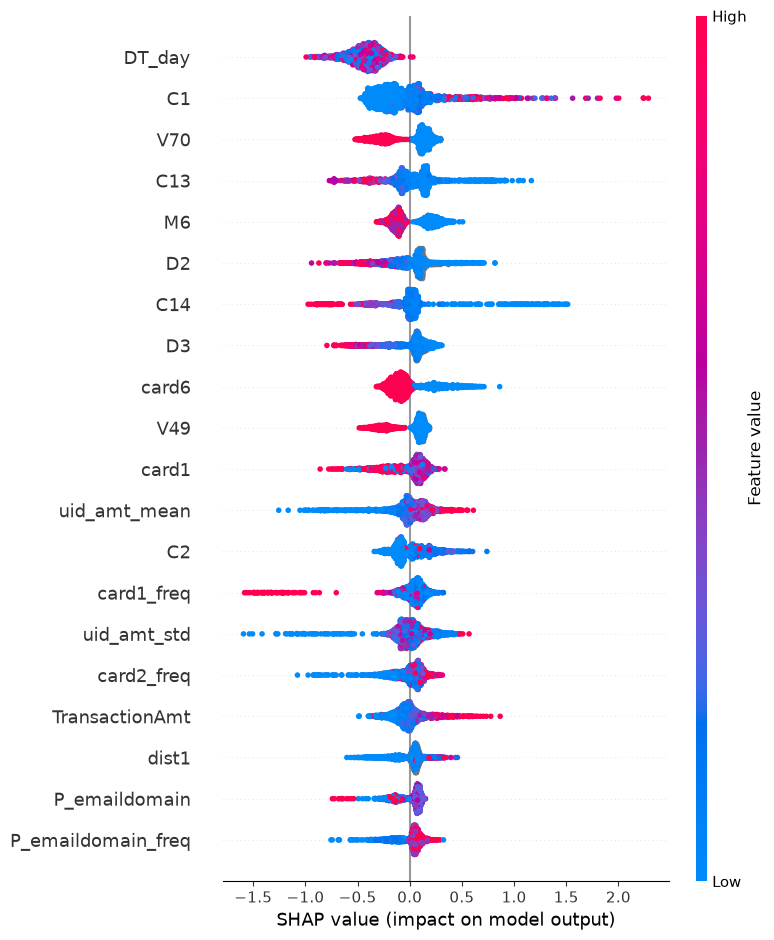

In [ ]:
import shap

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_val.sample(2000, random_state=RANDOM_STATE))

shap.summary_plot(shap_values, X_val.sample(2000, random_state=RANDOM_STATE), max_display=20)


In [ ]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
